In [7]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
import logging
import sys

from collections.abc import Callable
from pathlib import Path
from typing import Any

project_root = Path().resolve().parent
sys.path.append(str(project_root))

from scripts import (
    generate_dataset,
    optuna_search,
    predictions,
    training,
)
from experiments.plotting import _plot_SRE_distribution, view_correlation
from GNN.training.runners import MODEL_REGISTRY
from GNN.training.train_config import TrainConfig
from GNN.training.utils import collect_dataset_indices, to_scalar
from src.utils import configure_logger

import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt

In [9]:
logger = logging.getLogger(__name__)
logger.propagate = False
configure_logger(logging.INFO, logging.INFO)

True

In [10]:
Loader = Callable[..., Any]

# Data Visualization

In [34]:
seed = 542342
model_type="gnn"
epochs = 30
lr = 1e-4
loss_type = "huber"   # "mse" | "huber"
batch_size = 32
training_mode = "per_family"  # "global" | "per_family"
family = "random"  # required if training_mode == "per_family"
target = "sre"
target_variant = "sre_density"
split = "target"
training_data_dir = "../outputs/data/datasets_SRE"
model_save_path = "../outputs/models/random_model_gnn.pt"
show_progress=True
show_val_progress=False
log_every_n_batches=10
heartbeat_secs=60.0
epoch_time_warning_secs=600.0

In [35]:
model_hparams = {
    "gnn_hidden": 32,
    "gnn_heads": 4,
    "global_hidden": 128,
    "reg_hidden": 128,
    "num_layers": 3,
    "dropout_rate": 0.13173830279748305,
}

train_hparams = {
    "weight_decay": 0.0003324725858640221,
    "grad_clip": 1.0289214665544766,
    "early_stopping_patience": 10,
    "early_stopping_min_delta": 0.0,
}

In [36]:
VALID_FAMILIES = {"haar", "clifford", "quansistor", "random"}
if model_type not in MODEL_REGISTRY:
    msg = f"Unsupported model_type: {model_type}. Must be one of {sorted(MODEL_REGISTRY)}"
    raise ValueError(msg)

if training_mode not in {"global", "per_family"}:
    msg = "training_mode must be 'global' or 'per_family'"
    raise ValueError(msg)

if training_mode == "per_family":
    if family is None:
        raise ValueError("family must be provided when training_mode='per_family'")
    if family not in VALID_FAMILIES:
        msg = f"Invalid family: {family}. Must be one of {sorted(VALID_FAMILIES)}"
        raise ValueError(
            msg,
        )

logger.info(f"Starting training | model_type={model_type} | training_mode={training_mode} | family={family} | loss_type={loss_type}")
cfg = TrainConfig(
    epochs=epochs,
    lr=lr,
    loss_type=loss_type,
    batch_size=batch_size,
    training_mode=training_mode,
    family=family,
    target=target,
    show_progress=show_progress,
    show_val_progress=show_val_progress,
    log_batch_loss_every=log_every_n_batches,
    heartbeat=heartbeat_secs,
    epoch_warning=epoch_time_warning_secs,
)
logger.info("Training configuration done.")

model_hparams = {} if model_hparams is None else dict(model_hparams)
train_hparams = {} if train_hparams is None else dict(train_hparams)

family_filter = family if training_mode == "per_family" else None
family_projection = family if training_mode == "per_family" else None

logger.info("Collecting data paths...")
# data_paths = collect_files_path(training_data_dir, family=family_filter)
train_paths = collect_dataset_indices(
    training_data_dir,
    family=family_filter,
)
if not train_paths:
    raise RuntimeError("No data paths found.")
logger.info(f"Found {len(train_paths)} data paths.")
logger.info("Data paths collected.")

spec = MODEL_REGISTRY[model_type]
logger.info(f"Building loaders and model for model_type={model_type}...")

loader_fn: Loader = spec["build_loaders"]
returns_nodes_dim: bool = spec.get("returns_nodes_dim", False)
if returns_nodes_dim:
    train_loader, val_loader, test_loader, node_in_dim, global_in_dim, base_dataset = loader_fn(
        train_paths,
        batch_size=cfg.batch_size,
        seed=cfg.seed,
        train_split=cfg.train_split,
        val_split=cfg.val_split,
        family_projection=family_projection,
        target_variant=target_variant,
        split = split,
    )
else:
    train_loader, val_loader, test_loader, global_in_dim, base_dataset = loader_fn(
        train_paths,
        batch_size=cfg.batch_size,
        seed=cfg.seed,
        train_split=cfg.train_split,
        val_split=cfg.val_split,
        family_projection=family_projection,
        target_variant=target_variant,
        split = split,
    )
    node_in_dim = global_in_dim

KeyboardInterrupt: 

In [ ]:
print(base_dataset[0])

Data(x=[13, 17], edge_index=[2, 10], global_features=[153], y=[1], sre=[1], cid='random_q004_L001_s22550440', family='random', regime='generic_dense', n_qubits=[1], n_layers=[1], seed=[1], has_target=[1], backend='pennylane', method='fwht', representation='dense', n_bins=[1], count_rx_bin_0=[1], count_rx_bin_1=[1], count_rx_bin_2=[1], count_rx_bin_3=[1], count_rx_bin_4=[1], count_rx_bin_5=[1], count_rx_bin_6=[1], count_rx_bin_7=[1], count_rx_bin_8=[1], count_rx_bin_9=[1], count_rx_bin_10=[1], count_rx_bin_11=[1], count_rx_bin_12=[1], count_rx_bin_13=[1], count_rx_bin_14=[1], count_rx_bin_15=[1], count_rx_bin_16=[1], count_rx_bin_17=[1], count_rx_bin_18=[1], count_rx_bin_19=[1], count_rx_bin_20=[1], count_rx_bin_21=[1], count_rx_bin_22=[1], count_rx_bin_23=[1], count_rx_bin_24=[1], count_rx_bin_25=[1], count_rx_bin_26=[1], count_rx_bin_27=[1], count_rx_bin_28=[1], count_rx_bin_29=[1], count_rx_bin_30=[1], count_rx_bin_31=[1], count_rx_bin_32=[1], count_rx_bin_33=[1], count_rx_bin_34=[1]

In [ ]:
def plot_global_sre_distribution(df: pd.DataFrame, family: str, density: bool = True):
    sub = df[df["family"] == family].copy()

    col = "sre_density" if density else "sre"
    xlabel = "SRE / n_qubits" if density else "SRE"

    values = sub[col].dropna().to_numpy()

    plt.figure(figsize=(7, 4))
    plt.hist(values, bins=40, alpha=0.8)
    plt.xlabel(xlabel)
    plt.ylabel("Number of circuits")
    plt.title(f"{family}: global {xlabel} distribution")
    plt.tight_layout()
    plt.show()

def plot_sre_ecdf(df: pd.DataFrame, family: str, density: bool = True):
    sub = df[df["family"] == family].copy()

    col = "sre_density" if density else "sre"
    xlabel = "SRE / n_qubits" if density else "SRE"

    values = np.sort(sub[col].dropna().to_numpy())

    if len(values) == 0:
        print(f"No values for {family}")
        return

    y = np.arange(1, len(values) + 1) / len(values)

    plt.figure(figsize=(7, 4))
    plt.plot(values, y)
    plt.xlabel(xlabel)
    plt.ylabel("Cumulative fraction")
    plt.title(f"{family}: empirical CDF of {xlabel}")
    plt.tight_layout()
    plt.show()

def add_sre_bins(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    bins = [-1e-12, 1e-5, 0.05, 0.10, 0.20, 0.35, 0.50, 0.75, np.inf]
    labels = [
        "zero",
        "tiny",
        "very_low",
        "low",
        "medium_low",
        "medium",
        "high",
        "very_high",
    ]

    df["sre_bin"] = pd.cut(
        df["sre_density"],
        bins=bins,
        labels=labels,
        include_lowest=True,
    )

    return df

def plot_sre_vs_layers(df: pd.DataFrame, family: str):
    sub = df[df["family"] == family].copy()

    plt.figure(figsize=(7, 4))
    plt.scatter(
        sub["n_layers"],
        sub["sre_density"],
        s=12,
        alpha=0.35,
    )
    plt.xlabel("Number of layers")
    plt.ylabel("SRE / n_qubits")
    plt.title(f"{family}: SRE density vs depth")
    plt.tight_layout()
    plt.show()

def plot_sre_by_qubits(df: pd.DataFrame, family: str):
    sub = df[df["family"] == family].copy()

    plt.figure(figsize=(7, 4))
    sub.boxplot(column="sre_density", by="n_qubits")
    plt.suptitle("")
    plt.title(f"{family}: SRE density by number of qubits")
    plt.xlabel("n_qubits")
    plt.ylabel("SRE / n_qubits")
    plt.tight_layout()
    plt.show()

def plot_SRE_regime(output_dir: str, family: str):
    rows = []

    for path in Path(output_dir+"/"+family).rglob("*.pt"):
        d = torch.load(path, map_location="cpu")

        meta = d["meta"]
        controls = meta.get("sampling_controls", {})
        realized = meta.get("realized_stats", {})

        row = {
            "path": str(path),
            "family": meta["family"],
            "regime": meta["regime"],
            "n_qubits": meta["n_qubits"],
            "n_layers": meta["n_layers"],
            "seed": meta["seed"],
            "sre": float(d.get("sre", np.nan)),
            "sre_density": float(d.get("sre", np.nan)) / meta["n_qubits"],
        }

        row.update({f"ctrl_{k}": v for k, v in controls.items()})
        row.update({f"real_{k}": v for k, v in realized.items()})

        rows.append(row)

    df = pd.DataFrame(rows)

    for family in df["family"].unique():
        sub = df[(df["family"] == family) & np.isfinite(df["sre_density"])]

        plt.figure()
        sub.boxplot(column="sre_density", by="regime", rot=45)
        plt.title(f"{family}: SRE density by regime")
        plt.suptitle("")
        plt.ylabel("SRE / n_qubits")
        plt.tight_layout()
        plt.show()

In [ ]:
base_dataset[0]

Data(x=[13, 17], edge_index=[2, 10], global_features=[153], y=[1], sre=[1], cid='random_q004_L001_s22550440', family='random', regime='generic_dense', n_qubits=[1], n_layers=[1], seed=[1], has_target=[1], backend='pennylane', method='fwht', representation='dense', n_bins=[1], count_rx_bin_0=[1], count_rx_bin_1=[1], count_rx_bin_2=[1], count_rx_bin_3=[1], count_rx_bin_4=[1], count_rx_bin_5=[1], count_rx_bin_6=[1], count_rx_bin_7=[1], count_rx_bin_8=[1], count_rx_bin_9=[1], count_rx_bin_10=[1], count_rx_bin_11=[1], count_rx_bin_12=[1], count_rx_bin_13=[1], count_rx_bin_14=[1], count_rx_bin_15=[1], count_rx_bin_16=[1], count_rx_bin_17=[1], count_rx_bin_18=[1], count_rx_bin_19=[1], count_rx_bin_20=[1], count_rx_bin_21=[1], count_rx_bin_22=[1], count_rx_bin_23=[1], count_rx_bin_24=[1], count_rx_bin_25=[1], count_rx_bin_26=[1], count_rx_bin_27=[1], count_rx_bin_28=[1], count_rx_bin_29=[1], count_rx_bin_30=[1], count_rx_bin_31=[1], count_rx_bin_32=[1], count_rx_bin_33=[1], count_rx_bin_34=[1]

In [ ]:
def sre_row(data):
    return {
        "cid": data.cid,
        "family": data.family,
        "regime": data.regime,
        "n_qubits": int(data.n_qubits.item()),
        "n_layers": int(data.n_layers.item()),
        "seed": int(data.seed.item()),
        "sre": float(data.sre.item()),
        "y": float(data.y.item()),
        "sre_density": float(data.sre.item()) / data.n_qubits.item(),
    }

df = pd.DataFrame(
    sre_row(base_dataset[i])
    for i in range(len(base_dataset))
)

In [ ]:
df.head()

,cid,family,regime,n_qubits,n_layers,seed,sre,y,sre_density
0,random_q004_L001_s22550440,random,generic_dense,4,1,22550440,0.202442,0.050610,0.050610
1,random_q004_L001_s25064164,random,near_clifford,4,1,25064164,0.000129,0.000032,0.000032
2,random_q004_L001_s35019855,random,generic_dense,4,1,35019855,0.682258,0.170565,0.170565
3,random_q004_L001_s35413194,random,medium_angles,4,1,35413194,0.412548,0.103137,0.103137
4,random_q004_L001_s42486639,random,generic_dense,4,1,42486639,0.374010,0.093503,0.093503


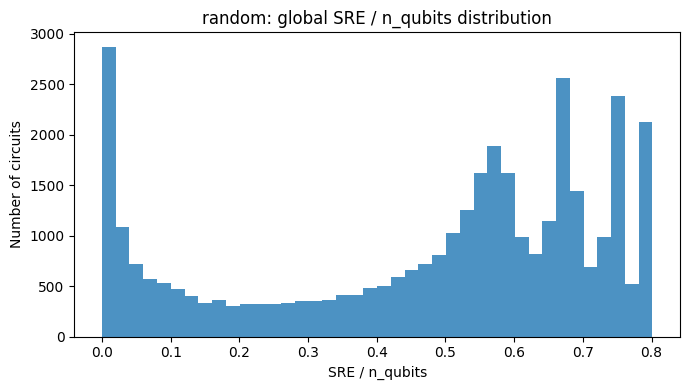

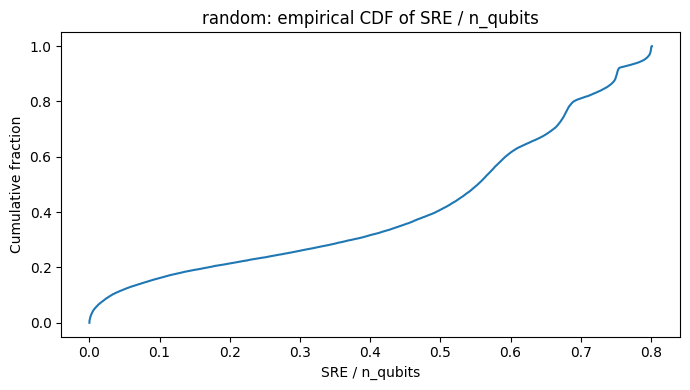

In [ ]:
plot_global_sre_distribution(df, family)
plot_sre_ecdf(df, family)

# Training

In [37]:
def run(
    model_type,
    epochs,
    lr,
    loss_type,
    batch_size,
    training_mode,
    family,
    target,
    target_variant,
    model_hparams,
    train_hparams,
    training_data_dir,
    model_save_path,
    split,
    plot_qubits=10,
    plot_layers=80,
):
    training(
        epochs=epochs,
        lr=lr,
        loss_type=loss_type,
        batch_size=batch_size,
        training_mode=training_mode,
        family=family,
        target=target,
        target_variant=target_variant,
        model_type=model_type,
        model_hparams=model_hparams,
        train_hparams=train_hparams,
        training_data_dir=training_data_dir,
        split=split,
        model_save_path=model_save_path,
        show_progress=True,
        show_val_progress=False,
        log_every_n_batches=10,
        heartbeat_secs=60.0,
        epoch_time_warning_secs=600.0,
    )
    training_scope = "family" if training_mode == "per_family" else "global"
    predictions(
        model_path=model_save_path,
        model_kind=model_type,
        training_scope=training_scope,
        loss_type=loss_type,
        model_family=family,
        dataset_root=training_data_dir,
        dataset_family=family,
        batch_size=batch_size,
        global_feature_variant="binned",
        node_feature_backend_variant=None,
        plot_n_layers=plot_layers,
        plot_n_qubits=plot_qubits,
        split_by_family=True,
        show_progress=True,
    )

    df = pd.read_csv(f"../outputs/predictions/{training_scope}/{model_type}_predictions_{family}.csv")
    cols_to_fix = ["n_qubits", "n_layers", "seed"]

    for col in cols_to_fix:
        df[col] = df[col].apply(to_scalar).astype(int)
    view_correlation(
        df,
        nq=plot_qubits,
        nl=plot_layers,
        col_x="target",
        col_y="prediction",
    )
    df = df[(df["n_qubits"] == plot_qubits) & (df["n_layers"] == plot_layers)]
    plt.figure(figsize=(8, 6))
    plt.scatter(df["target"], df["prediction"], alpha=0.7)
    plt.plot([df["target"].min(), df["target"].max()], [df["target"].min(), df["target"].max()], "r--")  # y=x line
    plt.xlabel("True SRE")
    plt.ylabel("Predicted SRE")
    plt.title("True vs Predicted SRE for Clifford Family (GNN Model)")

## Random

In [38]:
seed = 542342
model_type="gnn"
epochs = 30
lr = 1e-4
loss_type = "huber"   # "mse" | "huber"
batch_size = 32
training_mode = "per_family"  # "global" | "per_family"
family = "random"  # required if training_mode == "per_family"
target = "sre"
target_variant = "sre_density"
split = "target"
training_data_dir = "../outputs/data/datasets_SRE"
model_save_path = "../outputs/models/random_model_gnn_sre_density.pt"
show_progress=True
show_val_progress=False
log_every_n_batches=10
heartbeat_secs=60.0
epoch_time_warning_secs=600.0

model_hparams = {
    "gnn_hidden": 32,
    "gnn_heads": 4,
    "global_hidden": 128,
    "reg_hidden": 128,
    "num_layers": 3,
    "dropout_rate": 0.13173830279748305,
}

train_hparams = {
    "weight_decay": 0.0003324725858640221,
    "grad_clip": 1.0289214665544766,
    "early_stopping_patience": 10,
    "early_stopping_min_delta": 0.0,
}

In [39]:
run(
    model_type=model_type,
    epochs=epochs,
    lr=lr,
    loss_type=loss_type,
    batch_size=batch_size,
    training_mode=training_mode,
    family=family,
    target=target,
    target_variant=target_variant,
    model_hparams=model_hparams,
    train_hparams=train_hparams,
    training_data_dir=training_data_dir,
    split=split,
    model_save_path=model_save_path,
)

2026-06-04 11:37:58,829 - GNN.training.runners - INFO - Starting training | model_type=gnn | training_mode=per_family | family=random | loss_type=huber
2026-06-04 11:37:58,832 - GNN.training.runners - INFO - Training configuration done.
2026-06-04 11:37:58,833 - GNN.training.runners - INFO - Collecting data paths...
2026-06-04 11:37:58,836 - GNN.training.runners - INFO - Found 1 data paths.
2026-06-04 11:37:58,837 - GNN.training.runners - INFO - Data paths collected.
2026-06-04 11:37:58,838 - GNN.training.runners - INFO - Building loaders and model for model_type=gnn...


KeyboardInterrupt: 